## Trabajo Práctico
### Aprendizaje Automático I

##### Estudiantes: Carolina Ruiz, Rocio Quispe

#### Carga de librerías necesarias

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet, LassoCV, RidgeCV, ElasticNetCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

#### Carga de datos

In [2]:
file_path = 'uber_fares.csv'
df = pd.read_csv(file_path)

#### Contexto  
El proyecto trata sobre **Uber Inc.**, la compañía de taxis más grande del mundo. En este trabajo, nuestro objetivo es **predecir la tarifa de futuros viajes**.  

Uber brinda servicio a millones de clientes cada día, por lo que gestionar adecuadamente sus datos es clave para desarrollar nuevas estrategias de negocio y obtener mejores resultados.  

#### Variables del conjunto de datos  

**Variables explicativas:**  
- **key**: identificador único de cada viaje.  
- **pickup_datetime**: fecha y hora en que se inició el viaje.  
- **passenger_count**: cantidad de pasajeros en el vehículo (dato ingresado por el conductor).  
- **pickup_longitude**: longitud del punto de inicio del viaje.  
- **pickup_latitude**: latitud del punto de inicio del viaje.  
- **dropoff_longitude**: longitud del punto de destino.  
- **dropoff_latitude**: latitud del punto de destino.  

**Variable objetivo (target):**  
- **fare_amount**: costo del viaje en dólares.  

Visualización general del dataset.

In [3]:
df.head()

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5


#### **Visualización de los datos** (EDA)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   key                200000 non-null  int64  
 1   date               200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


Se observan muy pocos datos nulos en las columnas relacionadas a la bajada de los viajes. Se continúa con las métricas generales de las columnas numéricas.

In [5]:
df.describe()

,key,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


Siendo que la variable objetivo es **fare_amount**, y observando que tiene datos negativos, se decide eliminarlos ya que no hay una manera viable de imputarlos.

In [6]:
df = df[df['fare_amount']>=0]

Se continúa con los valores nulos para luego eliminarlos. Los nulos vistos en dropoffs pertenecen al mismo registro.

In [7]:
df[df.isna().any(axis=1)]

,key,date,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
87946,32736015,2013-07-02 03:51:57.0000001,24.1,2013-07-02 03:51:57 UTC,-73.950581,40.779692,NaN,NaN,0


In [8]:
df = df.dropna()

Ya que se eliminaron datos nulos relacionados a latitudes y longitudes, se procede a visualizar las ubicaciones de bajadas y subidas de los viajes hechos.

In [9]:
info_mapeo = df[['pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude']]

In [10]:
import geopandas as gpd
import contextily as ctx

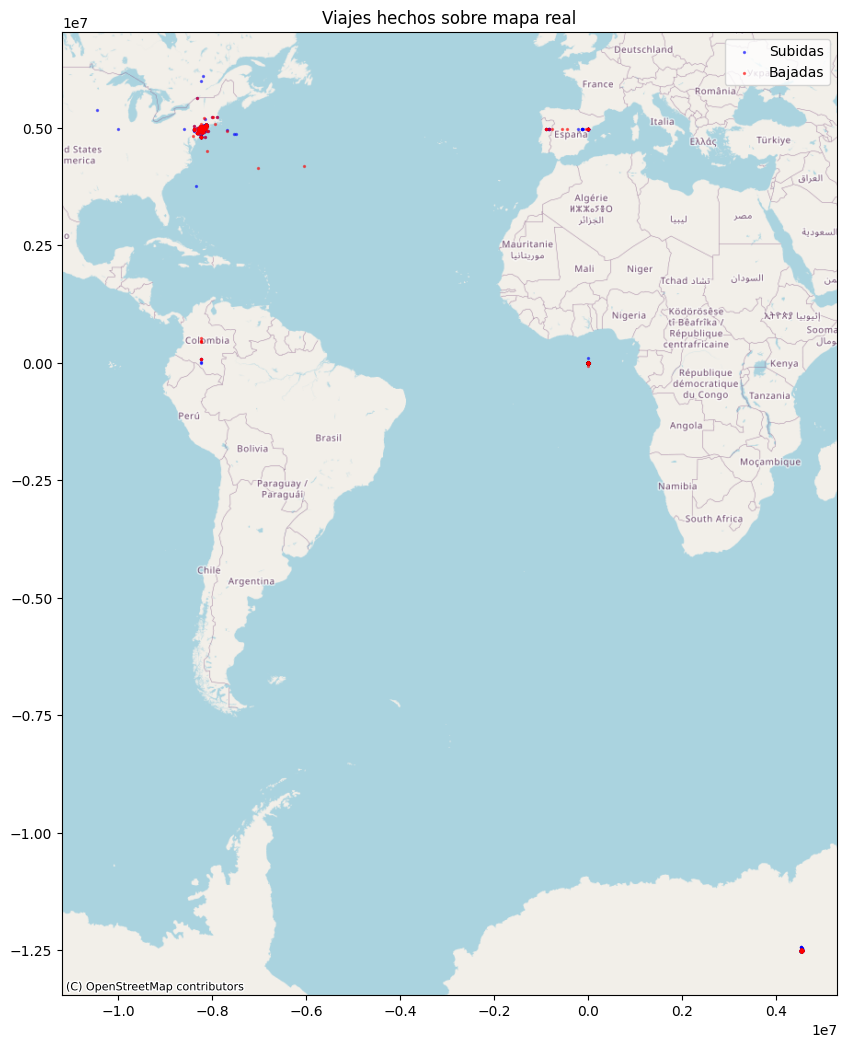

In [11]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['pickup_longitude'], info_mapeo['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(info_mapeo['dropoff_longitude'], info_mapeo['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()

El mapa demuestra que muchos viajes pertenecen a zonas geográficas variadas. Posiblemente el dataset mezcló viajes de distintos paises, por error. Por razones de practicidad, solo se seleccionarán viajes hechos dentro de territorio de New York ya que en principio, el trabajo debería limitarse a esa zona.
Se tendrán en cuenta estos datos para la selección nueva:
- Latitud: entre 40 y 41 grados.
- Longitud: entre -75 y -72 grados.

In [12]:
def in_ny(lat, lon):
    return 40 <= lat <= 41 and -75 <= lon <= -72

# Filtro pickups
mask_pickup = df.apply(lambda row: in_ny(row['pickup_latitude'], row['pickup_longitude']), axis=1)

# Filtro dropoffs
mask_dropoff = df.apply(lambda row: in_ny(row['dropoff_latitude'], row['dropoff_longitude']), axis=1)

# Se guardan viajes donde pickup y dropoff están en USA
df_ny = df[mask_pickup & mask_dropoff].copy()

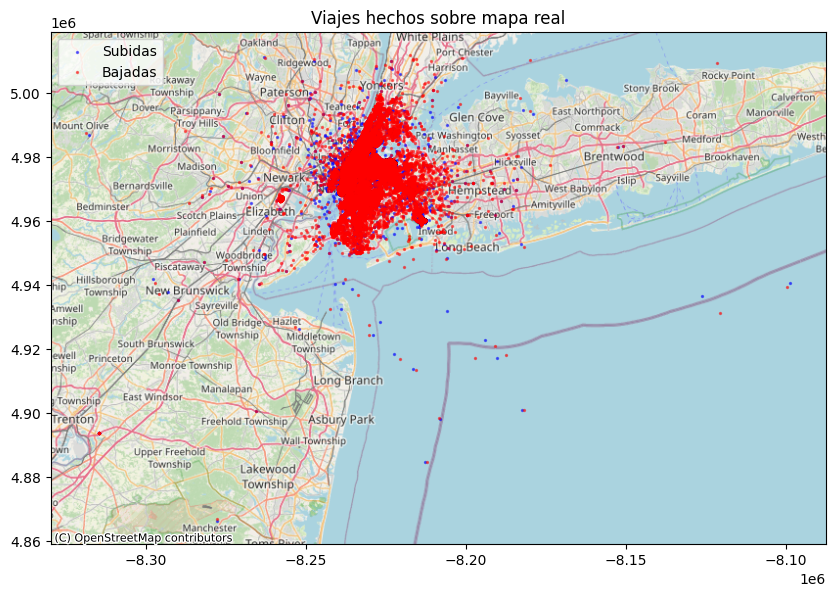

In [13]:
# GeoDataFrame de pickups y dropoffs
gdf_pickup = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['pickup_longitude'], df_ny['pickup_latitude']), crs="EPSG:4326")
gdf_dropoff = gpd.GeoDataFrame(df_ny, geometry=gpd.points_from_xy(df_ny['dropoff_longitude'], df_ny['dropoff_latitude']), crs="EPSG:4326")

# Proyección métrica
gdf_pickup = gdf_pickup.to_crs(epsg=3857)
gdf_dropoff = gdf_dropoff.to_crs(epsg=3857)

fig, ax = plt.subplots(figsize=(10, 14))
gdf_pickup.plot(ax=ax, markersize=2, color="blue", alpha=0.5, label="Subidas")
gdf_dropoff.plot(ax=ax, markersize=2, color="red", alpha=0.5, label="Bajadas")

# Mapa base
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

plt.legend()
plt.title("Viajes hechos sobre mapa real")
plt.show()

In [14]:
print(f'El dataset original tiene {len(df)} registros. El dataset, tiene {len(df_ny)}. Por lo tanto, se eliminaron {len(df)-len(df_ny)} registros.')

El dataset original tiene 199982 registros. El dataset, tiene 195681. Por lo tanto, se eliminaron 4301 registros.


Una vez que el dataset solo se limita a los datos de Nueva York, se visualizan las distribuciones de los datos numéricos más revelantes de df_ny.

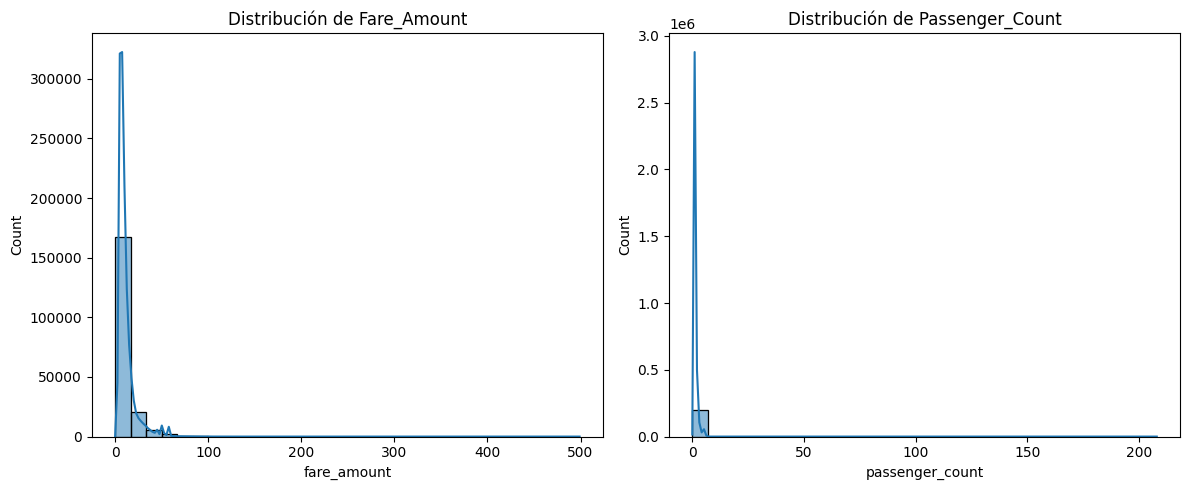

In [15]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df_ny['fare_amount'], bins=30, kde=True)
plt.title('Distribución de Fare_Amount')

plt.subplot(1, 2, 2)
sns.histplot(df_ny['passenger_count'], bins=30, kde=True)
plt.title('Distribución de Passenger_Count')

plt.tight_layout()
plt.show()

Las distribuciones son sesgadas a la derecha en ambos casos, con una gran concentración de datos en valores bajos y colas largas hacia valores altos (posibles outliers). Post split, se tendrán en cuenta estos datos para crear nuevas variables o eliminar outliers.

Antes de hacerlo, se eliminan variables que no se usarán o se adaptarán formatos.

In [16]:
df_ny['pickup_datetime'] = pd.to_datetime(df_ny['pickup_datetime'], utc=True)

In [17]:
df_ny = df_ny.drop(columns=['date', 'key'])

Siendo que fare_amount va a ser nuestra variable objetivo, se examinan sus métricas principales para chequear lo visto en el último histograma: presencia de datos cercanos o iguales a cero.

In [18]:
df_ny['fare_amount'].describe()

count    195681.000000
mean         11.331933
std           9.716312
min           0.000000
25%           6.000000
50%           8.500000
75%          12.500000
max         499.000000
Name: fare_amount, dtype: float64

In [19]:
df_ny[df_ny['fare_amount']==0]

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
20744,0.0,2015-04-22 23:25:07+00:00,-73.658897,40.805199,-73.658897,40.805199,1
22182,0.0,2010-03-20 02:59:51+00:00,-73.994366,40.755395,-73.998718,40.854853,2
156738,0.0,2015-02-17 08:48:08+00:00,-73.937714,40.758541,-73.937721,40.758541,1


Como se considera anormal la presencia de tarifas iguales a cero y siendo que son solo tres registros, se eliminan antes del split.

In [20]:
df_ny = df_ny[df_ny['fare_amount'] != 0]

#### **División de dataset a train y test**

In [21]:
y = df_ny['fare_amount']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(df_ny.drop(columns='fare_amount'), df_ny['fare_amount'], test_size=0.2, random_state=42)

In [23]:
print(f'Tamaño de X_train {X_train.shape}; tamaño de X_test: {X_test.shape}')

Tamaño de X_train (156542, 6); tamaño de X_test: (39136, 6)


#### **Creación de nuevas variables**

Para descartar ideas a la hora de crear variables nuevas, se visualizan las variaciones de **fare_amount** con respecto a la hora y el día de la semana.

In [24]:
prov = df_ny.copy()

In [25]:
prov['hora'] = prov['pickup_datetime'].dt.hour

In [26]:
tarifa_hora = prov.groupby('hora')['fare_amount'].mean()
tarifa_hora.sort_values(ascending=False).head(10)

hora
5     16.010885
4     14.038949
14    11.971845
6     11.939965
15    11.895739
16    11.781528
1     11.599465
3     11.592307
0     11.581566
23    11.558086
Name: fare_amount, dtype: float64

<Axes: xlabel='hora'>

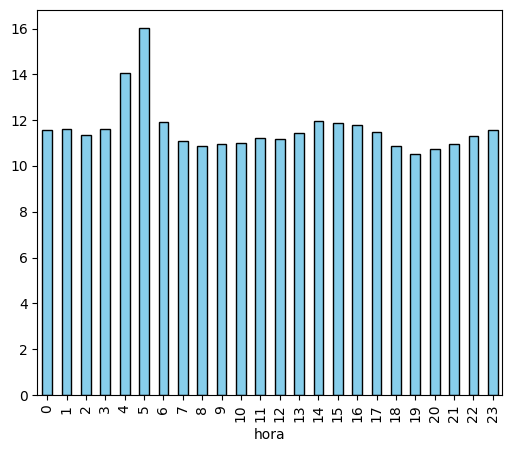

In [27]:
tarifa_hora.plot(kind='bar', figsize=(6, 5), color='skyblue', edgecolor='black')

Teniendo en cuenta el cálculo agrupado y el gráfico anterior, la variación más significativa se produce entre las 4 y 5 de la madrugada. El resto del día se mantiene bastante estable. Sin embargo, también se podrían considerar destacables las franjas de 00 a 03 y 14 a 16. Se tendrá en cuenta para dummies.

In [28]:
prov['dia'] = prov['pickup_datetime'].dt.dayofweek

In [29]:
tarifa_dia = prov.groupby('dia')['fare_amount'].mean()
tarifa_dia.sort_values(ascending=False).head(10)

dia
6    11.716066
3    11.478998
4    11.397170
0    11.368981
2    11.331076
1    11.070122
5    10.998752
Name: fare_amount, dtype: float64

<Axes: xlabel='dia'>

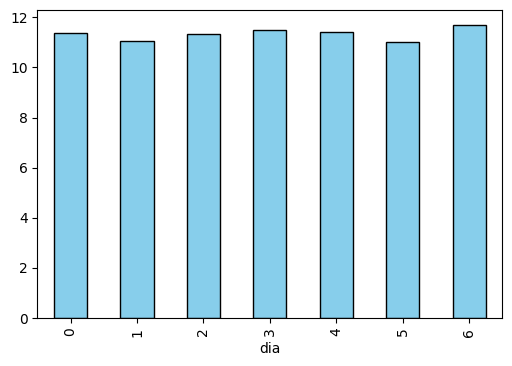

In [30]:
tarifa_dia = prov.groupby('dia')['fare_amount'].mean()
tarifa_dia.plot(kind='bar', figsize=(6,4), color='skyblue', edgecolor='black')

El promedio de la tarifa por día no parece tener una gran variación por día, salvo levemente por los domingos (columna 6). Se evaluará si realmente tiene impacto para un modelo predictivo.

In [31]:
prov['quincena'] = prov['pickup_datetime'].dt.day.apply(lambda d: 1 if d <= 15 else 2) 

In [32]:
tarifa_quincena = prov.groupby('quincena')['fare_amount'].mean()
tarifa_quincena.head()

quincena
1    11.315992
2    11.347818
Name: fare_amount, dtype: float64

Asimismo, la quincena del mes en el que se ubica el viaje tampoco parece tener relevancia. Se descarta para hacer variables nuevas.
En síntesis, se procede a crear variables relacionadas al día (si es domingo o no) y franjas horarias (las captadas como relevantes anteriormente).

In [33]:
def var_domingo(df):
    """
    Crea una variable indicadora 'es_domingo' (True/False)
    basada en la columna 'pickup_datetime'
    """
    df['day'] = df['pickup_datetime'].dt.dayofweek
    df['es_domingo'] = df['day'] == 6
    df['es_domingo'] = df['es_domingo'].astype(int)

    df = df.drop(columns=['day'])
    return df

In [34]:
X_train = var_domingo(X_train)
X_test = var_domingo(X_test)

In [35]:
def var_franja_horaria(df):
    df['hour'] = df['pickup_datetime'].dt.hour
    condic_hora = [
    (df['hour']>=0) & (df['hour']<=3),
    (df['hour']>=4) & (df['hour']<=5),
    (df['hour']>=14) & (df['hour']<=16)]
    valores = ['resto_madrugada', 'pico_madrugada', 'pico_tarde']

    df['franja_hora'] = np.select(condic_hora, valores, default='resto_horas')

    df = df.drop(columns=['hour'])
    return df

In [36]:
X_train = var_franja_horaria(X_train)
X_test = var_franja_horaria(X_test)

Por otro lado, se crea una columna para conocer bien los **KMs** hechos por viaje, al considerarse sumamente útil para predecir tarifas.

In [37]:
def manhattan_dist(lat1, lon1, lat2, lon2):
    """
    Calcula la Distancia de Manhattan entre dos
    puntos geográficos en kilómetros.

    Parámetros:
    lat1, lon1: Latitud y Longitud del punto de partida.
    lat2, lon2: Latitud y Longitud del punto de destino.

    Devuelve:
    La distancia aproximada de Manhattan en kilómetros.
    """
    R = 6371

    delta_lat = np.abs(lat2 - lat1)
    delta_lon = np.abs(lon2 - lon1)

    lat_to_km = 111.32
    lon_to_km = 111.32

    distance_km = (delta_lat * lat_to_km) + (delta_lon * lon_to_km)

    return distance_km

In [38]:
X_train['KMs'] = manhattan_dist(X_train['pickup_latitude'], X_train['pickup_longitude'],
                      X_train['dropoff_latitude'], X_train['dropoff_longitude'])

X_test['KMs'] = manhattan_dist(X_test['pickup_latitude'], X_test['pickup_longitude'],
                      X_test['dropoff_latitude'], X_test['dropoff_longitude'])

Se visualiza la distribución de **KMs** en X_train.

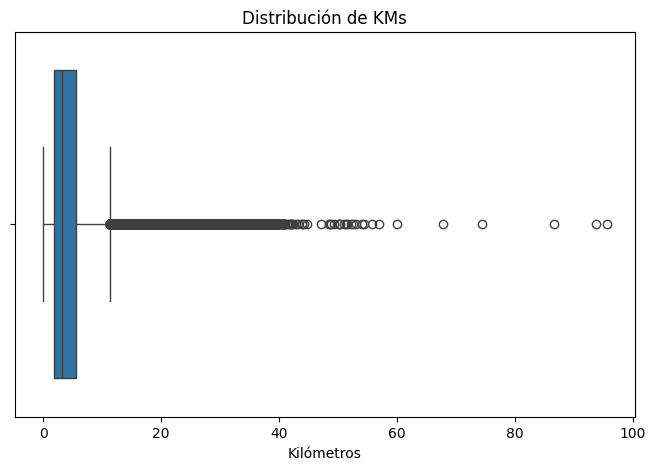

In [39]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=X_train['KMs'])
plt.title('Distribución de KMs')
plt.xlabel('Kilómetros')
plt.show()

Se confirma la existencia de valores en cero o cerca de cero. Se evalúa más en detalle.

In [40]:
X_train['KMs'].describe()

count    156542.000000
mean          4.894537
std           5.580906
min           0.000000
25%           1.830435
50%           3.137888
75%           5.658466
max          95.598722
Name: KMs, dtype: float64

In [41]:
cant_cero = len(X_train[X_train['KMs']==0])
print(f'De {len(X_train)} registros, {cant_cero} cuentan con KMs=0')

De 156542 registros, 1551 cuentan con KMs=0


Los valores KMs=0 representan apróx. el 0.99% de X_train. Al ser tan ínfimo, se elige eliminarlos de ambos conjuntos.

In [42]:
X_train = X_train[X_train['KMs']>0]
X_test = X_test[X_test['KMs']>0]

In [43]:
X_train['KMs'].describe()

count    154991.000000
mean          4.943517
std           5.587133
min           0.000111
25%           1.864165
50%           3.170282
75%           5.702924
max          95.598722
Name: KMs, dtype: float64

Resulta curioso que, si bien se eliminaron los viajes sin KMs hechos, aún persisten registros con menos de un kilómetro hecho. Si bien puede resultar extraño, se opta por dejar los viajes que han hecho al menos 100 metros (0.1 KMs), al ser solo una cuadra. Luego, se observa su nueva distribución.

In [44]:
X_train = X_train[X_train['KMs'] >= 0.1]
X_test = X_test[X_test['KMs'] >= 0.1]

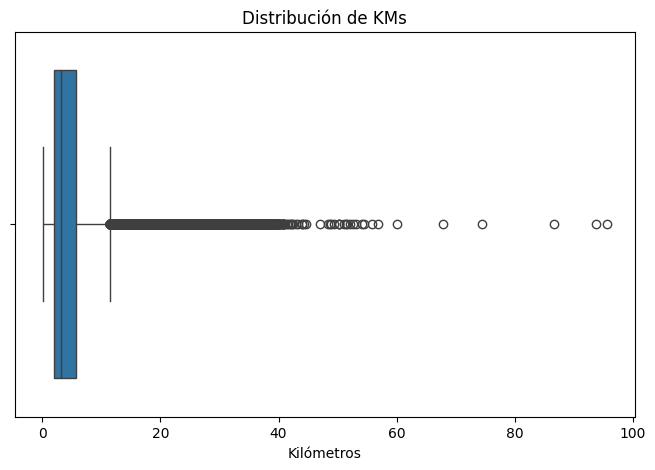

In [45]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=X_train['KMs'])
plt.title('Distribución de KMs')
plt.xlabel('Kilómetros')
plt.show()

Tras una breve investigación externa, se llegó a la conclusión de que la variable **passenger_count** si bien aparece como numérica, en realidad se puede tomar como categórica. La cantidad de pasajeros solo define si el viaje implica el uso de un auto normal o un auto más amplio. Por esta razón, se procede a transformarla variables más acordes.
- Paquetería = 0 pasajeros
- UberX = 1 a 4 pasajeros
- UberXL = 5 o más pasajeros.

In [46]:
def var_pasajeros(df):
    condiciones = [
    (df['passenger_count'] == 0),
    (df['passenger_count'] >=5)]
    valores = ['paqueteria', 'uberxl']

    df['tipo_viaje'] = np.select(condiciones, valores, default='uberx')
    df =  df.drop(columns=['passenger_count'])
    return df

In [47]:
X_train = var_pasajeros(X_train)
X_test = var_pasajeros(X_test)

Antes de continuar, se eliminan las columnas que ya no sirven como 'pickup_datetime', 'pickup_longitude', 'pickup_latitude', 'dropoff_longitude', 'dropoff_latitude'.

In [48]:
X_train = X_train.drop(columns=['pickup_datetime', 'pickup_longitude', 'pickup_latitude','dropoff_longitude', 'dropoff_latitude'])
X_test = X_test.drop(columns=['pickup_datetime', 'pickup_longitude', 'pickup_latitude','dropoff_longitude', 'dropoff_latitude'])

Se transforman las variables nuevas a dummies con OneHotEncoder.

In [49]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

In [50]:
columnas_categoricas = ['franja_hora', 'tipo_viaje']
columnas_numericas = ['es_domingo', 'KMs']


one_hot_t = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), columnas_categoricas)],
    remainder='passthrough')

In [51]:
X_train_array = one_hot_t.fit_transform(X_train)

# Obtener los Nombres de las Nuevas Columnas - incluye los nombres de las columnas One-Hot y las passthrough
feature_names = one_hot_t.get_feature_names_out()

X_test_array = one_hot_t.transform(X_test)

# Reconstruir los DataFrames de Pandas
X_train = pd.DataFrame(X_train_array, 
                               columns=feature_names, 
                               index=X_train.index)

X_test = pd.DataFrame(X_test_array, 
                              columns=feature_names, 
                              index=X_test.index)

In [52]:
def limpiar_nombres(cols):
    """Elimina los prefijos de ColumnTransformer."""
    return [col.split('__')[-1] for col in cols]

X_train.columns = limpiar_nombres(X_train.columns)
X_test.columns = limpiar_nombres(X_test.columns)

In [53]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154205 entries, 186216 to 124693
Data columns (total 9 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   franja_hora_pico_madrugada   154205 non-null  float64
 1   franja_hora_pico_tarde       154205 non-null  float64
 2   franja_hora_resto_horas      154205 non-null  float64
 3   franja_hora_resto_madrugada  154205 non-null  float64
 4   tipo_viaje_paqueteria        154205 non-null  float64
 5   tipo_viaje_uberx             154205 non-null  float64
 6   tipo_viaje_uberxl            154205 non-null  float64
 7   es_domingo                   154205 non-null  float64
 8   KMs                          154205 non-null  float64
dtypes: float64(9)
memory usage: 11.8 MB


**Correlaciones entre variables candidatas, sobre X_train**

In [54]:
matriz_corr = X_train.corr()

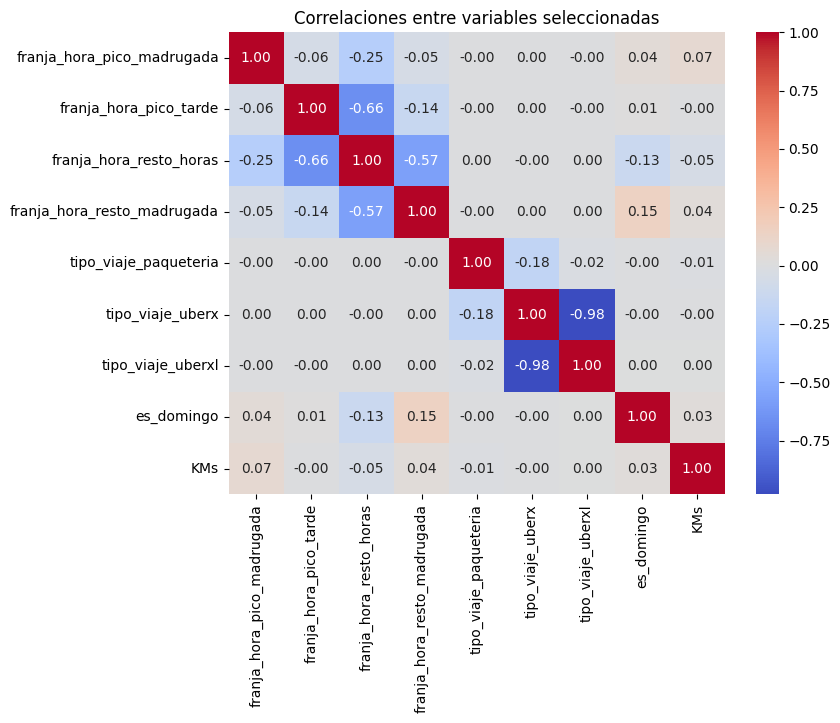

In [55]:
plt.figure(figsize=(8,6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlaciones entre variables seleccionadas')
plt.show()

Las variables tipo_viaje_uberxl y tipo_viaje_uberx tienen una relación lineal negativa casi perfecta. Esto significa que cuando el valor de una variable aumenta, el valor de la otra variable tiende a disminuir, y viceversa. Se elimina **tipo_viaje_uberx** para evitar multicolinealidad con su versión en UberXL.

In [56]:
X_train = X_train.drop(columns=['tipo_viaje_uberx'])
X_test = X_test.drop(columns=['tipo_viaje_uberx'])

**Examinación de estructura y contenido de variables de X_train**

In [57]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 154205 entries, 186216 to 124693
Data columns (total 8 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   franja_hora_pico_madrugada   154205 non-null  float64
 1   franja_hora_pico_tarde       154205 non-null  float64
 2   franja_hora_resto_horas      154205 non-null  float64
 3   franja_hora_resto_madrugada  154205 non-null  float64
 4   tipo_viaje_paqueteria        154205 non-null  float64
 5   tipo_viaje_uberxl            154205 non-null  float64
 6   es_domingo                   154205 non-null  float64
 7   KMs                          154205 non-null  float64
dtypes: float64(8)
memory usage: 10.6 MB


Se mantiene lo visto en la etapa de limpieza: muchos outliers en KMs. Pueden ser normales dado el hecho de que el dataset presenta viajes hechos en un territorio muy grande. Sin embargo, se elige escalar los datos para que no afecten estos outliers al modelo.

In [58]:
robust_scaler = RobustScaler()
X_train['KMs_scaled'] = robust_scaler.fit_transform(X_train[['KMs']])
X_test['KMs_scaled'] = robust_scaler.transform(X_test[['KMs']]) 

Se elimina **KMs** para que no genere problemas en el modelo.

In [59]:
X_train = X_train.drop(columns=['KMs'])
X_test = X_test.drop(columns=['KMs'])

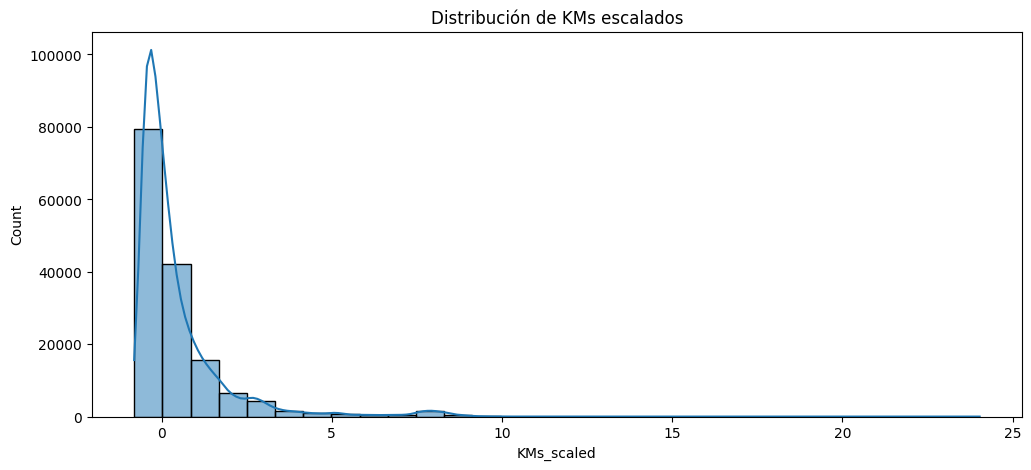

In [60]:
plt.figure(figsize=(12, 5))

sns.histplot(X_train['KMs_scaled'], bins=30, kde=True)
plt.title('Distribución de KMs escalados')

plt.show()

**Validación cruzada**

In [61]:
from sklearn.model_selection import cross_val_score

In [62]:
model_cross = LinearRegression()

In [63]:
y_train = y_train.loc[X_train.index]
y_test = y_test.loc[X_test.index]
# Aplica la validación cruzada
# cv=5 indica que el algoritmo dividirá los datos en 5 subconjuntos (folds)
# scoring='neg_mean_squared_error' te da el MSE, pero con un signo negativo
scores = cross_val_score(model_cross, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

print("Resultados de la validación cruzada (MSE):")
print(scores)
print(f"MSE promedio: {-scores.mean():.2f}")
print(f"Desviación estándar del MSE: {scores.std():.2f}")

Resultados de la validación cruzada (MSE):
[-17.24877424 -18.82408272 -17.99126492 -18.17582369 -19.1625182 ]
MSE promedio: 18.28
Desviación estándar del MSE: 0.67


En promedio, el cuadrado de la diferencia entre el valor real de la tarifa y el valor predicho por el modelo es la raiz de 18.28, lo cual es $4.28.

#### **Modelado Inicial**

Se asegura que todas los columnas cuenten con la misma escala, por lo que se hace un **escalado de X_train**.

In [64]:
# Definición y entrenamiento
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

#### **Evaluación**

In [65]:
# Predicciones
y_train_pred = model.predict(X_train)
y_test_pred  = model.predict(X_test)

# Métricas
def evaluar_modelo(y_true, y_pred, nombre="modelo"):
    mse  = mean_squared_error(y_true, y_pred)
    rmse = mse**0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"Resultados {nombre}:")
    print(f"  MSE : {mse:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  MAE : {mae:.4f}")
    print(f"  R²  : {r2:.4f}")
    print("-"*40)

evaluar_modelo(y_train, y_train_pred, "LinearRegression (train)")
evaluar_modelo(y_test, y_test_pred, "LinearRegression (test)")

Resultados LinearRegression (train):
  MSE : 18.2753
  RMSE: 4.2750
  MAE : 2.3864
  R²  : 0.7949
----------------------------------------
Resultados LinearRegression (test):
  MSE : 20.1241
  RMSE: 4.4860
  MAE : 2.4038
  R²  : 0.7785
----------------------------------------


**Observaciones**:

 El rendimiento en train y test son muy cercanos (R2 con 0.60 y 0.58, respectivamente) indica que el modelo está generalizando bien y no está sufriendo de overfitting. Precisión: un MAE de 3.37 es razonable para un modelo inicial de Regresión Lineal, ya que es cercano  lo visto en VC.

#### **Prueba con métodos de gradiente descendiente**

In [66]:
from sklearn.linear_model import SGDRegressor

Batch GD:

In [67]:
def batch_gradient_descent_adaptado(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Implementa el Descenso de Gradiente por Lotes (BGD) para Regresión Lineal.
    Usa X_test/y_test para monitorear el error de generalización.
    
    NOTA: Las variables de entrada se convierten a NumPy y se ajusta la forma (n, 1) internamente.
    """
    # 1. CONVERSIÓN Y RE-SHAPE (Para evitar MemoryError)
    # Convertir a NumPy array
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    
    # Asegurar que las etiquetas y sean vectores columna (n, 1)
    y_train = np.array(y_train).reshape(-1, 1)
    y_test = np.array(y_test).reshape(-1, 1)
    
    # Obtener shapes
    n = X_train.shape[0] # Ejemplos de entrenamiento
    m = X_train.shape[1] # Características
    p = X_test.shape[0]  # Ejemplos de prueba

    # 2. Poner columna de unos a las matrices X (Bias Trick)
    X_train_b = np.hstack((np.ones((n, 1)), X_train))
    X_test_b = np.hstack((np.ones((p, 1)), X_test))

    # 3. Inicializar pesos aleatorios
    W = np.random.randn(m + 1).reshape(m + 1, 1)

    train_errors = []
    test_errors = []

    # 4. Bucle de Entrenamiento (Épocas)
    for _ in range(epochs):
        # A. Predicción y Error de Entrenamiento
        prediction_train = np.matmul(X_train_b, W) 
        # La resta ahora funciona porque y_train y prediction_train son (n, 1)
        error_train = y_train - prediction_train  
        train_mse = np.mean(error_train ** 2)
        train_errors.append(train_mse)

        # B. Predicción y Error de Prueba (Monitoreo)
        prediction_test = np.matmul(X_test_b, W) 
        error_test = y_test - prediction_test 
        test_mse = np.mean(error_test ** 2)
        test_errors.append(test_mse)

        # C. Calcular el Gradiente (usando el lote completo)
        grad_sum = np.sum(error_train * X_train_b, axis=0)
        grad_mul = -2/n * grad_sum 
        gradient = grad_mul.reshape(-1, 1)

        W = W - (lr * gradient)

    # 5. Graficar Errores
    plt.figure(figsize=(12, 6))
    plt.plot(train_errors, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Iteraciones (BGD, lr={lr})')
    plt.grid(True)
    plt.show()

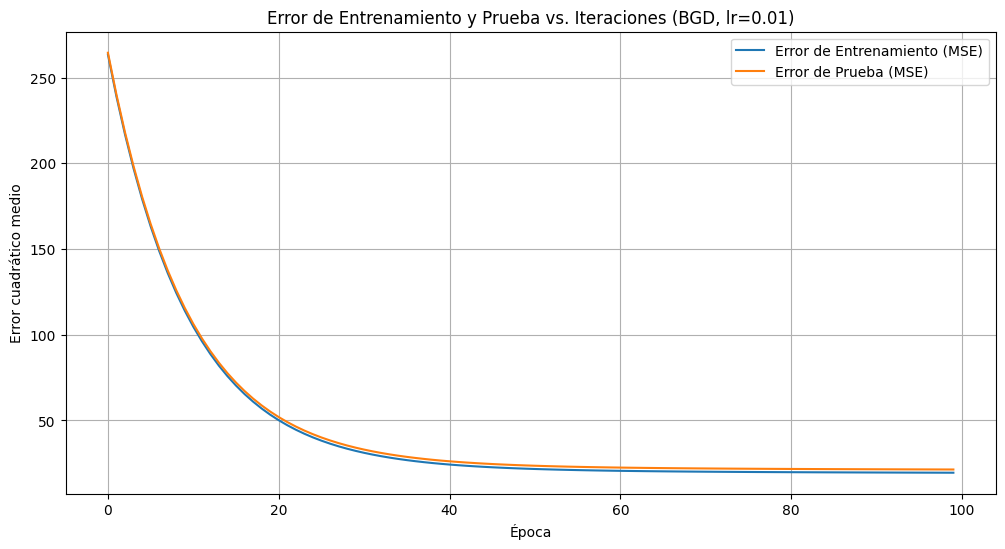

In [68]:
batch_gradient_descent_adaptado(X_train, y_train, X_test, y_test)

SGB:

In [69]:
def stochastic_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100):
    """
    Implementa el Descenso de Gradiente Estocástico (SGD) para Regresión Lineal.
    Usa un solo ejemplo aleatorio para cada actualización.
    """
    # 1. CONVERSIÓN Y RE-SHAPE (Solución al MemoryError y Shape)
    # Convertir a NumPy array
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    
    # Asegurar que las etiquetas y sean vectores columna (n, 1)
    y_train = np.array(y_train).reshape(-1, 1)
    y_test = np.array(y_test).reshape(-1, 1)
    
    n = X_train.shape[0]
    m = X_train.shape[1]

    # 2. Agregar Bias Trick
    X_train = np.hstack((np.ones((n, 1)), X_train))
    X_test = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    # 3. Inicializar pesos
    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors_plot = []  # Para el gráfico (MSE promedio por época)
    test_errors_plot = []   # Para el gráfico (MSE promedio por época)

    for i in range(epochs):
        # Permutación aleatoria de los datos
        # Esto es crucial para SGD: asegurar que cada ejemplo sea visto aleatoriamente
        permutation = np.random.permutation(n)
        X_train = X_train[permutation]
        y_train = y_train[permutation]
        
        # Lista para almacenar los MSEs de cada ejemplo dentro de la época
        epoch_train_mse = [] 

        for j in range(n):
            # Obtener el j-ésimo ejemplo de la permutación
            # Nota: .reshape(1, -1) asegura que x_sample sea una fila [1 x (m+1)]
            x_sample = X_train[j].reshape(1, -1) 
            y_sample = y_train[j].reshape(1, -1) 

            # A. Predicción y Error (con un solo dato)
            prediction = np.matmul(x_sample, W)
            error = y_sample - prediction

            # El MSE para un punto es solo el error al cuadrado:
            mse_sample = error ** 2
            epoch_train_mse.append(mse_sample[0, 0]) # Almacenar el MSE del punto

            # B. Cálculo de Gradiente y Actualización
            # Gradiente (derivada del error cuadrático para un punto): -2 * error * x_i
            # x_sample.T.reshape(-1, 1) asegura la forma (m+1, 1) para la resta
            gradient = -2 * error * x_sample.T 
            
            W = W - (lr * gradient)
        
        # C. Monitoreo (Una vez por Época)
        # 1. Error de Entrenamiento (Promedio de los n puntos vistos en la época)
        train_errors_plot.append(np.mean(epoch_train_mse))
        
        # 2. Error de Prueba (Evaluado con los pesos actuales W sobre todo X_test)
        prediction_test = np.matmul(X_test, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors_plot.append(test_mse)


    # 4. Graficar Errores 
    plt.figure(figsize=(12, 6))
    # En SGD, el eje X debe representar las épocas, no todas las iteraciones de puntos.
    plt.plot(train_errors_plot, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors_plot, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Épocas (SGD, lr={lr})')
    plt.grid(True)
    plt.show()

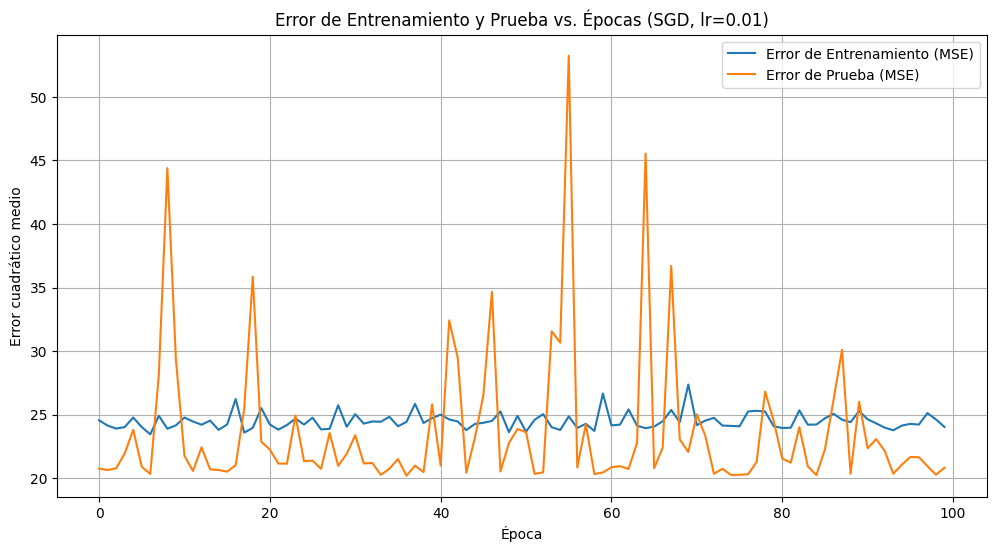

In [70]:
stochastic_gradient_descent(X_train, y_train, X_test, y_test)

Por Mini-Lotes (MBGD)

In [71]:
def mini_batch_gradient_descent(X_train, y_train, X_test, y_test, lr=0.01, epochs=100, batch_size=64):
    """
    Implementa Mini-Batch GD para Regresión Lineal. 
    Actualiza los pesos usando un subconjunto de datos (mini-lote) en cada iteración.
    """
    # 1. CONVERSIÓN Y RE-SHAPE (Solución al MemoryError y Shape)
    X_train = np.array(X_train)
    X_test = np.array(X_test)
    y_train = np.array(y_train).reshape(-1, 1) # Asegura la forma (n, 1)
    y_test = np.array(y_test).reshape(-1, 1)
    
    n = X_train.shape[0]
    m = X_train.shape[1]

    # 2. Agregar Bias Trick
    X_train_b = np.hstack((np.ones((n, 1)), X_train))
    X_test_b = np.hstack((np.ones((X_test.shape[0], 1)), X_test))

    W = np.random.randn(m + 1).reshape(-1, 1)

    train_errors_plot = [] # Almacena el MSE promedio por época
    test_errors_plot = []  # Almacena el MSE de prueba una vez por época

    for i in range(epochs):
        # Permutación y Shuffling de los datos
        permutation = np.random.permutation(n)
        X_shuffled = X_train_b[permutation]
        y_shuffled = y_train[permutation]

        epoch_train_mse = [] # Lista temporal para los MSEs de los mini-lotes
        
        # 3. Iterar sobre los mini-lotes
        for j in range(0, n, batch_size):
            # Obtener el mini-lote
            x_batch = X_shuffled[j:j+batch_size, :]
            y_batch = y_shuffled[j:j+batch_size] # Ya es (n_batch, 1)

            # A. Cálculo del Error y Predicción
            prediction = np.matmul(x_batch, W)
            error = y_batch - prediction
            
            # Monitoreo del error del mini-lote
            mse_batch = np.mean(error ** 2)
            epoch_train_mse.append(mse_batch)

            # B. Cálculo del Gradiente y Actualización
            # Gradiente: -2/batch_size * X_transpuesta * error
            gradient = -2 * np.matmul(x_batch.T, error) / batch_size
            W = W - (lr * gradient)
        
        # 4. Monitoreo por Época (Cruce de Validación)
        
        # Error de Entrenamiento (Promedio de todos los mini-lotes vistos en la época)
        train_errors_plot.append(np.mean(epoch_train_mse))
        
        # Error de Prueba (Evaluado con los pesos actuales W sobre todo X_test)
        prediction_test = np.matmul(X_test_b, W)
        error_test = y_test - prediction_test
        test_mse = np.mean(error_test ** 2)
        test_errors_plot.append(test_mse)


    # 5. Graficar Errores
    # 
    plt.figure(figsize=(12, 6))
    plt.plot(train_errors_plot, label='Error de Entrenamiento (MSE)')
    plt.plot(test_errors_plot, label='Error de Prueba (MSE)')
    plt.xlabel('Época')
    plt.ylabel('Error cuadrático medio')
    plt.legend()
    plt.title(f'Error de Entrenamiento y Prueba vs. Épocas (Mini-Batch GD, size={batch_size}, lr={lr})')
    plt.grid(True)
    plt.show()

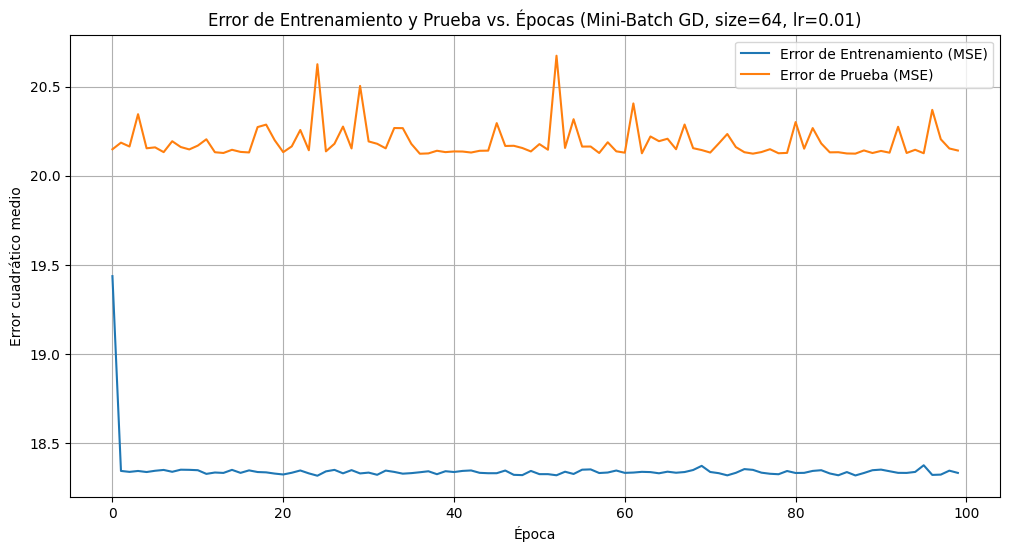

In [72]:
mini_batch_gradient_descent(X_train, y_train, X_test, y_test)

**Observaciones:**

**Descenso de Gradiente por Lotes (BGD)**:

- Convergencia: El error cae rápidamente al principio (hasta la Época 40 aproximadamente) y luego se estabiliza justo por debajo de un MSE de 25.
- Estabilidad: Es el método más estable; la dirección del gradiente es siempre precisa porque se calcula promediando el error de todo el dataset (154,205 ejemplos).
- Generalización: Las curvas de entrenamiento y prueba siguen caminos casi idénticos y terminan muy cerca, lo que confirma una excelente generalización y ausencia de overfitting.

**Descenso de Gradiente Estocástico (SGD)**:

- Convergencia: El error promedio del entrenamiento se mantiene relativamente estable alrededor de 24, pero la variación es muy alta.
- Estabilidad: Es el método más inestable. La actualización de pesos se basa en un solo ejemplo a la vez, por lo que la dirección del gradiente es muy ruidosa y salta mucho, lo que dificulta asentarse en un mínimo exacto.
- Picos de Prueba: Los picos altos del error de prueba (llegando a $70$) son un artefacto de este ruido extremo; las actualizaciones de pesos pueden alejar momentáneamente el modelo del mínimo.
- Velocidad: En teoría, SGD es el más rápido por época, pero la convergencia al punto más preciso es más lenta y errática.

**Descenso de Gradiente por Mini-Lotes (Mini-Batch GD):**

- Convergencia: Es el método que alcanza el error de entrenamiento más bajo (MSE 18.4) y lo hace casi inmediatamente (en la primera época).
- Estabilidad: La curva es mucho más estable que SGD y aprovecha la eficiencia del cálculo matricial de BGD.
- Generalización y Ruido: El error de prueba es consistentemente más alto que el de entrenamiento (MSE 20.1), lo cual indica un ligero gap de generalización. El ruido es mínimo y no impide la convergencia rápida.

#### **Con métodos de regularización (Lasso, Ridge, Elastic Net)**

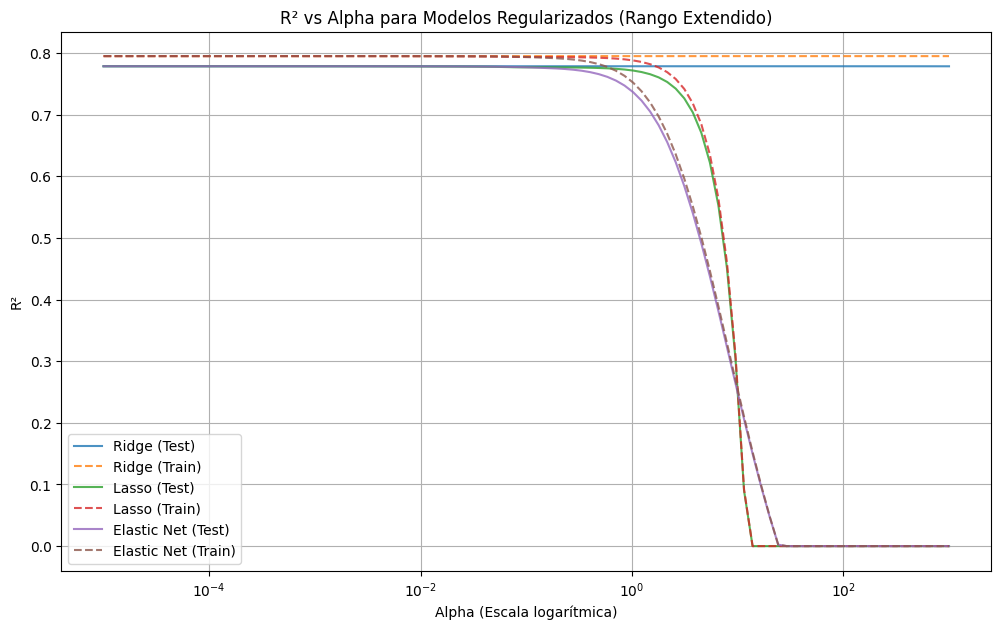

In [73]:
alphas = np.logspace(-5, 3, 100)
results = []

for alpha in alphas:
    # --- 1. ENTRENAR MODELOS ---
    
    # RIDGE
    ridge_model = Ridge(alpha=alpha)
    ridge_model.fit(X_train, y_train)
    
    # LASSO
    lasso_model = Lasso(alpha=alpha, max_iter=10000)
    lasso_model.fit(X_train, y_train)
    
    # ELASTIC NET
    elastic_net_model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=10000)
    elastic_net_model.fit(X_train, y_train)
    
    # --- 2. EVALUAR Y GUARDAR RESULTADOS (por Modelo y Conjunto) ---

    modelos = [('Ridge', ridge_model), ('Lasso', lasso_model), ('Elastic Net', elastic_net_model)]

    for nombre, modelo in modelos:
        
        # A. EVALUACIÓN EN CONJUNTO DE PRUEBA (TEST)
        y_pred_test = modelo.predict(X_test)
        results.append({
            "Modelo": nombre, "Alpha": alpha, "Conjunto": "test",
            "R2": r2_score(y_test, y_pred_test),
            "MSE": mean_squared_error(y_test, y_pred_test)
        })

        # B. EVALUACIÓN EN CONJUNTO DE ENTRENAMIENTO (TRAIN)
        y_pred_train = modelo.predict(X_train)
        results.append({
            "Modelo": nombre, "Alpha": alpha, "Conjunto": "train",
            "R2": r2_score(y_train, y_pred_train),
            "MSE": mean_squared_error(y_train, y_pred_train)
        })

df_results = pd.DataFrame(results)

## Gráfico de R² vs Alpha con los tres modelos
plt.figure(figsize=(12,7))
for model_name in ['Ridge','Lasso', 'Elastic Net']:
    # Graficar rendimiento de Prueba (Test)
    subset_test = df_results[(df_results['Modelo']==model_name) & (df_results['Conjunto']=='test')]
    plt.plot(subset_test['Alpha'], subset_test['R2'], label=f"{model_name} (Test)", linestyle='-', alpha=0.8)

    # Graficar rendimiento de Entrenamiento (Train)
    subset_train = df_results[(df_results['Modelo']==model_name) & (df_results['Conjunto']=='train')]
    plt.plot(subset_train['Alpha'], subset_train['R2'], label=f"{model_name} (Train)", linestyle='--', alpha=0.8)

plt.xscale('log')
plt.xlabel("Alpha (Escala logarítmica)")
plt.ylabel("R²")
plt.title("R² vs Alpha para Modelos Regularizados (Rango Extendido)")
plt.legend()
plt.grid(True)
plt.show()

In [74]:
def metricas_conj(df, conj):
    metricas = df[df['Conjunto'] == conj].copy()

    mejores_3 = metricas.groupby('Modelo', group_keys=False).apply(
    # Para cada modelo, selecciona las 3 filas con el R2 más alto
    lambda x: x.nlargest(3, 'R2'))

    return mejores_3

In [75]:
metricas_conj(df_results, 'train')

,Modelo,Alpha,Conjunto,R2,MSE
5,Elastic Net,0.000010,train,0.79495,18.275292
11,Elastic Net,0.000012,train,0.79495,18.275292
17,Elastic Net,0.000015,train,0.79495,18.275292
3,Lasso,0.000010,train,0.79495,18.275292
9,Lasso,0.000012,train,0.79495,18.275292
15,Lasso,0.000015,train,0.79495,18.275292
7,Ridge,0.000012,train,0.79495,18.275292
13,Ridge,0.000015,train,0.79495,18.275292
19,Ridge,0.000017,train,0.79495,18.275292


In [76]:
metricas_conj(df_results, 'test')

,Modelo,Alpha,Conjunto,R2,MSE
4,Elastic Net,0.000010,test,0.778517,20.124096
10,Elastic Net,0.000012,test,0.778517,20.124098
16,Elastic Net,0.000015,test,0.778517,20.124100
2,Lasso,0.000010,test,0.778517,20.124099
8,Lasso,0.000012,test,0.778517,20.124101
14,Lasso,0.000015,test,0.778517,20.124104
0,Ridge,0.000010,test,0.778517,20.124088
6,Ridge,0.000012,test,0.778517,20.124088
12,Ridge,0.000015,test,0.778517,20.124088


**Observaciones:**

La diferencia en el R2 entre Train y Test es mínima: 0.795 - 0.779 = 0.016 (menos del 2%). Esto quiere decir que una brecha tan pequeña indica que el modelo aprendió los patrones fundamentales de los datos de entrenamiento sin memorizar el ruido específico de esas muestras. La capacidad predictiva del modelo en datos nuevos (Prueba) es casi idéntica a su capacidad en datos ya vistos. Esto es el objetivo de la generalización buscada.

**Visualización de residuos**

In [77]:
def analizar_residuos_optimos(X_train, y_train, X_test, y_test, df_results):
    """
    Identifica el mejor Alpha (basado en R2 en 'test') para cada modelo, 
    re-entrena los modelos, calcula los residuos en el conjunto de prueba y los grafica.
    """
    # 1. Encontrar el Alpha óptimo para cada modelo
    df_test = df_results[df_results['Conjunto'] == 'test'].copy()
    idx_optimos = df_test.groupby('Modelo')['R2'].idxmax()
    alphas_optimos = df_test.loc[idx_optimos, ['Modelo', 'Alpha']].set_index('Modelo')['Alpha'].to_dict()

    residuos = {}
    
    # 2. Re-entrenar y calcular residuos
    for modelo_nombre, alpha_optimo in alphas_optimos.items():
        
        # Seleccionar el objeto de modelo correcto
        if modelo_nombre == 'Ridge':
            modelo = Ridge(alpha=alpha_optimo)
        elif modelo_nombre == 'Lasso':
            modelo = Lasso(alpha=alpha_optimo, max_iter=10000)
        elif modelo_nombre == 'Elastic Net':
            modelo = ElasticNet(alpha=alpha_optimo, l1_ratio=0.5, max_iter=10000)
        else:
            continue
            
        # Entrenar el modelo
        modelo.fit(X_train, y_train)
        
        # Calcular predicciones en el conjunto de prueba
        y_pred = modelo.predict(X_test)
        
        # Calcular los residuos (y_real - y_pred)
        residuos[modelo_nombre] = np.array(y_test).ravel() - y_pred.ravel()
        
    # 3. Graficar la distribución de los residuos 
    fig, axes = plt.subplots(1, 3, figsize=(18, 8))
    fig.suptitle('Distribución de Residuos en el Conjunto de Prueba', fontsize=16)

    modelos = ['Ridge', 'Lasso', 'Elastic Net']
    
    for i, modelo in enumerate(modelos):
        if modelo in residuos:
            sns.histplot(residuos[modelo], kde=True, ax=axes[i], bins=50)
            axes[i].set_title(f'Modelo: {modelo} (α={alphas_optimos[modelo]:.2e})')
            axes[i].set_xlabel('Residuo (Real - Predicho)')
            # Dibujar la línea en cero para verificar el sesgo
            axes[i].axvline(0, color='red', linestyle='--', linewidth=1) 
            
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

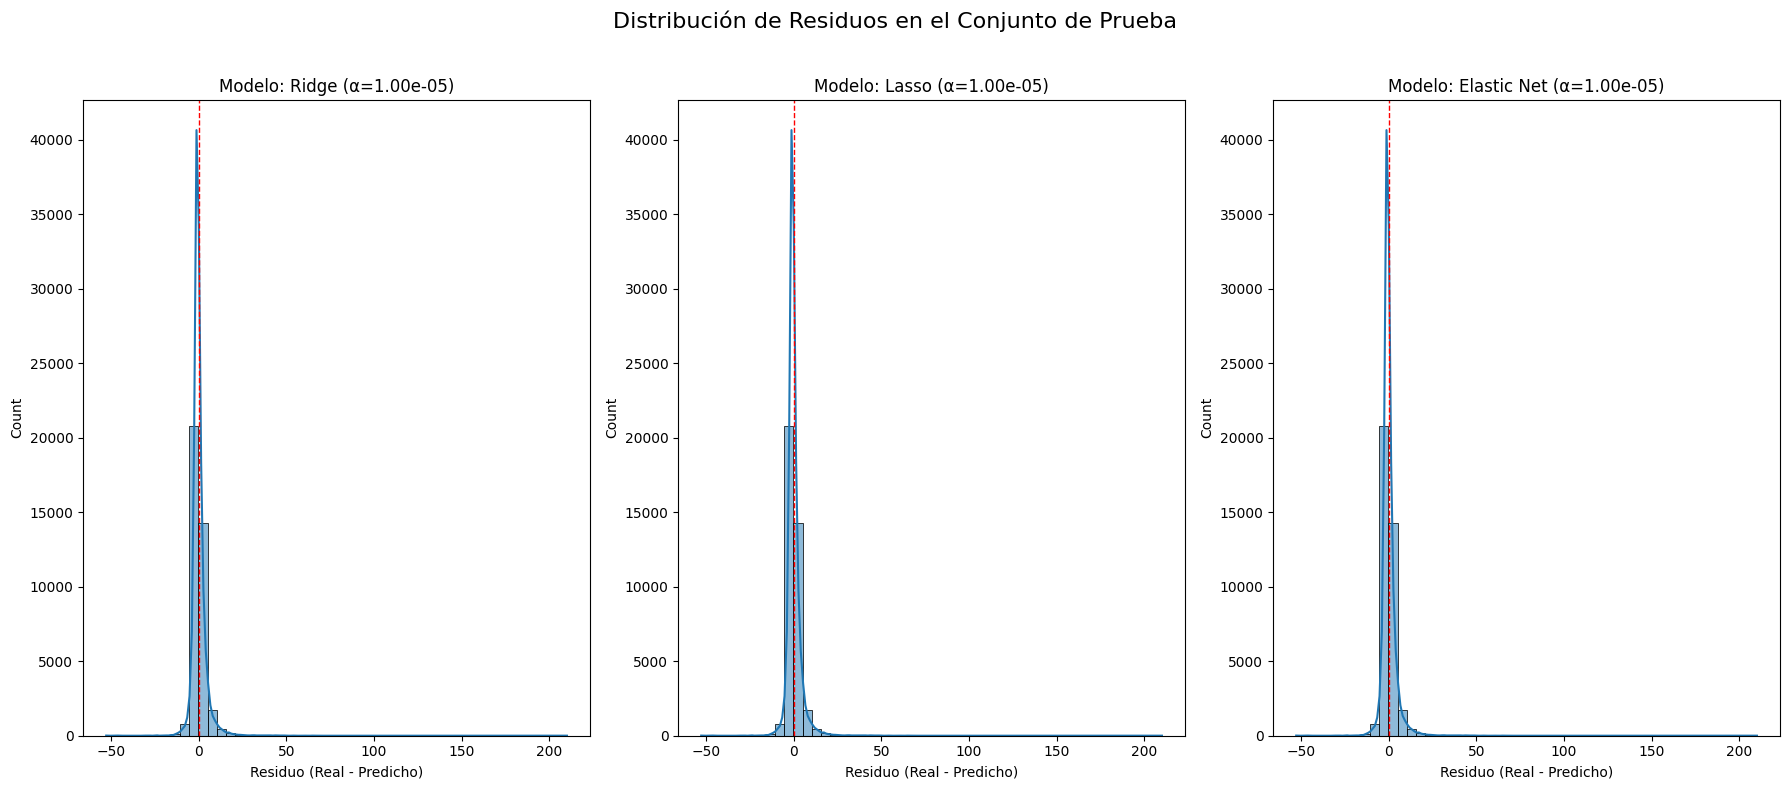

In [78]:
analizar_residuos_optimos(X_train, y_train, X_test, y_test, df_results)

**Observaciones:**

La tendencia general de los residuos es concentrarse alrededor de cero con una forma de campana. Sugiere que los errores del modelo se distribuyen de manera aproximadamente normal. El pico de la campana se alinea perfectamente con la línea roja central (cero). Esto confirma que el modelo no tiene sesgo sistémico; los errores aleatorios de subestimación y sobreestimación se equilibran.

Sin embargo, aunque la parte central es normal, los gráficos muestran colas largas y pesadas, que se extienden hasta 200. Esto quiere decir que el modelo falla sustancialmente en predecir un pequeño porcentaje de los viajes. Es probable que la alta varianza de la variable objetivo (la tarifa) esté provocando estos errores extremos, y al modelo le faltan características clave para explicar estos viajes atípicos.


#### Optimización de hiperparámetros

**De gradiente descendiente**

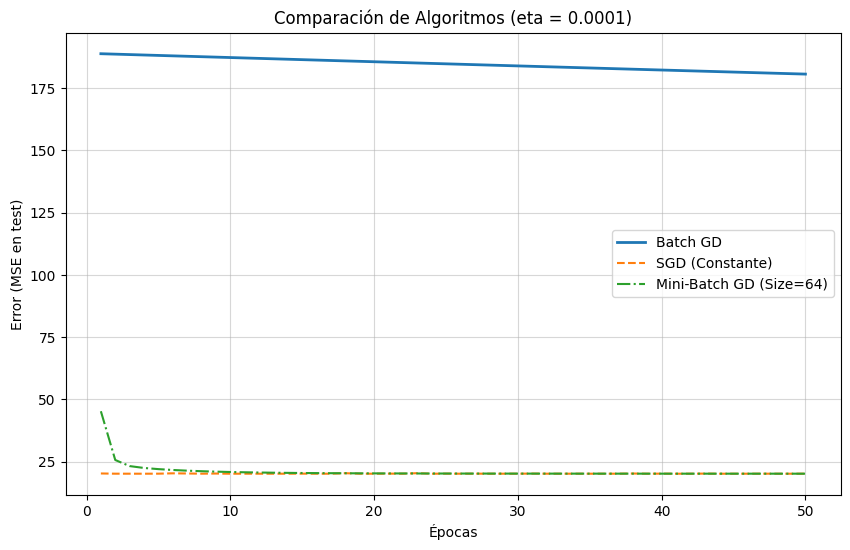

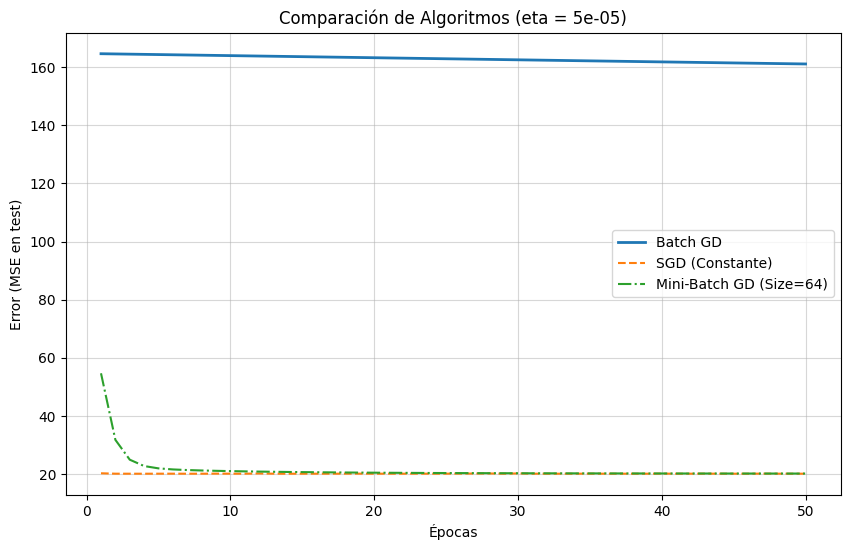

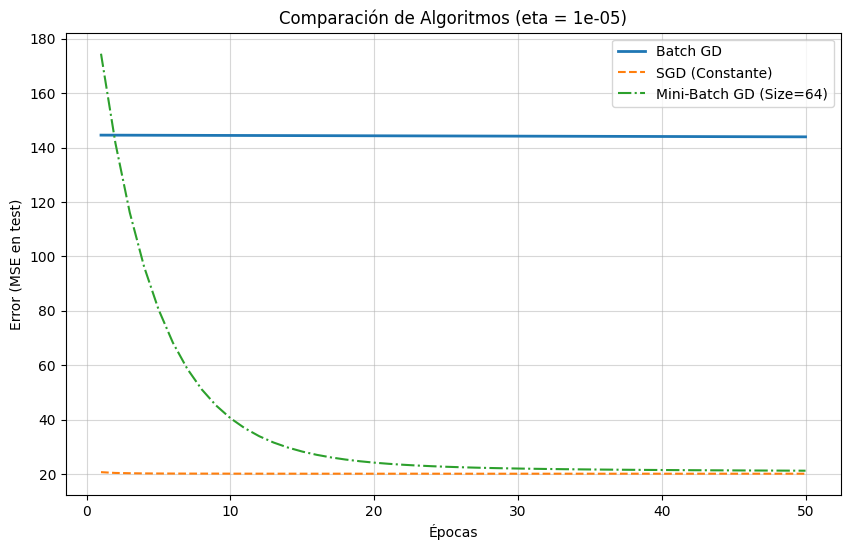

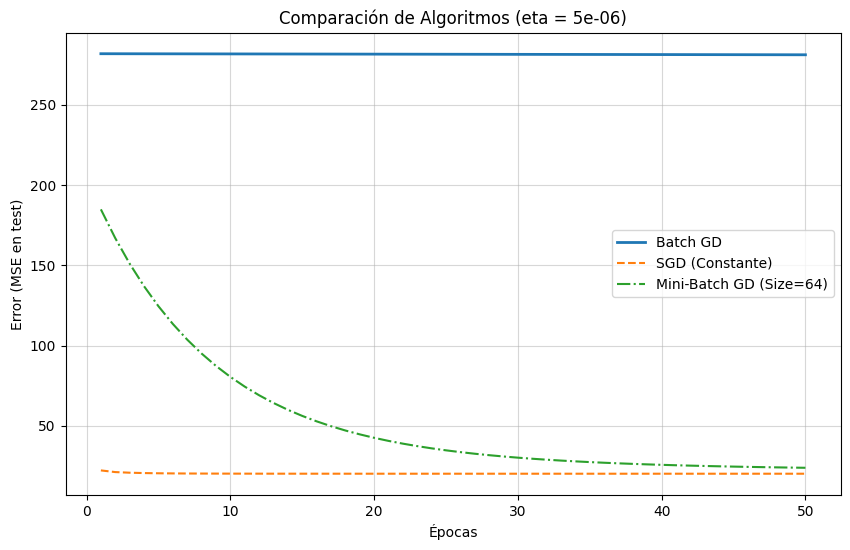

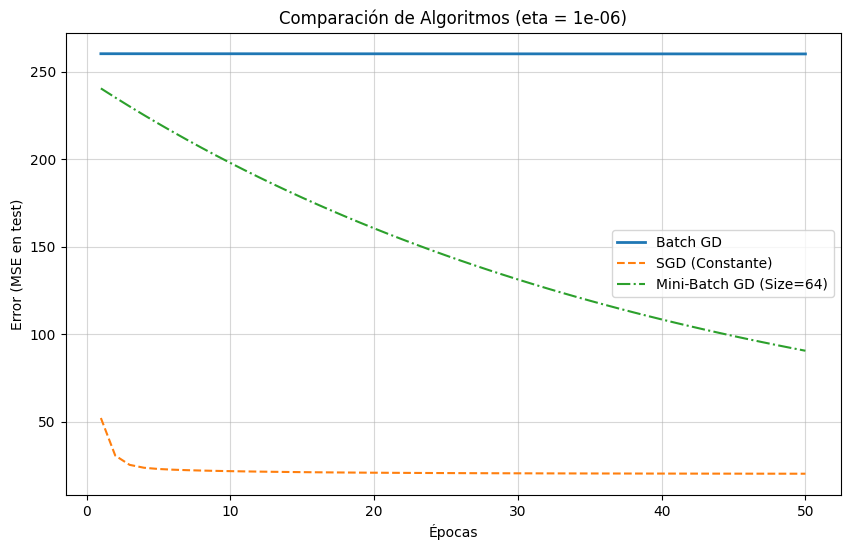

In [82]:
X_train_np = np.asarray(X_train); X_test_np = np.asarray(X_test)
y_train_np = np.asarray(y_train).reshape(-1, 1); y_test_np = np.asarray(y_test).reshape(-1, 1)
X_train_bias = np.c_[np.ones((len(X_train_np), 1)), X_train_np]
X_test_bias = np.c_[np.ones((len(X_test_np), 1)), X_test_np]

# Utilizaremos las variables *_bias y *_np para la ejecución:
m = len(X_train_np) 
n_features = X_train_np.shape[1]

# --- Hiperparámetros y Experimento ---

n_epochs = 50
batch_size = 64
# Reducimos las tasas iniciales para evitar divergencia y NaN.
etas = [0.0001, 0.00005, 0.00001, 0.000005, 0.000001]

# Bucle principal para probar cada tasa de aprendizaje
for eta in etas:
    
    # Inicialización de pesos (limpia para cada experimento)
    theta_batch = np.random.randn(n_features + 1, 1)
    theta_sgd = np.random.randn(n_features + 1, 1)
    theta_mbgd = np.random.randn(n_features + 1, 1)

    errors = {"batch": [], "sgd": [], "minibatch": []}
    
    for epoch in range(n_epochs):
        # Barajar los datos en cada época
        permutation = np.random.permutation(m)
        X_shuffled = X_train_bias[permutation]
        y_shuffled = y_train_np[permutation]

        # 1. Descenso de Gradiente por Lotes (BGD)
        grad_batch = 2 / m * X_train_bias.T.dot(X_train_bias.dot(theta_batch) - y_train_np)
        theta_batch -= eta * grad_batch
        
        
        # 2. Descenso de Gradiente Mini-Lote (MBGD)
        for i in range(0, m, batch_size):
            # Obtener el mini-lote
            xi_mbgd = X_shuffled[i:i + batch_size]
            yi_mbgd = y_shuffled[i:i + batch_size]
            
            # Gradiente y Actualización (con ETA CONSTANTE)
            grad_mbgd = 2 / len(xi_mbgd) * xi_mbgd.T.dot(xi_mbgd.dot(theta_mbgd) - yi_mbgd)
            theta_mbgd -= eta * grad_mbgd

        # 3. Descenso de Gradiente Estocástico (SGD)
        for i in range(m):
            # Obtener una sola muestra
            xi_sgd = X_shuffled[i:i + 1]
            yi_sgd = y_shuffled[i:i + 1]
            
            # Gradiente y Actualización (con ETA CONSTANTE)
            grad_sgd = 2 * xi_sgd.T.dot(xi_sgd.dot(theta_sgd) - yi_sgd)
            theta_sgd -= eta * grad_sgd
            
        
        # MONITOREO
        
        # Calcular errores en test
        y_pred_batch = X_test_bias.dot(theta_batch)
        y_pred_sgd = X_test_bias.dot(theta_sgd)
        y_pred_mbgd = X_test_bias.dot(theta_mbgd)

        errors["batch"].append(mean_squared_error(y_test_np, y_pred_batch))
        errors["sgd"].append(mean_squared_error(y_test_np, y_pred_sgd))
        errors["minibatch"].append(mean_squared_error(y_test_np, y_pred_mbgd))

    # Graficar por cada eta 
    plt.figure(figsize=(10, 6))
    plt.plot(range(1, n_epochs + 1), errors["batch"], label="Batch GD", linewidth=2)
    plt.plot(range(1, n_epochs + 1), errors["sgd"], label="SGD (Constante)", linestyle='--')
    plt.plot(range(1, n_epochs + 1), errors["minibatch"], label=f"Mini-Batch GD (Size={batch_size})", linestyle='-.')
    
    plt.xlabel("Épocas")
    plt.ylabel("Error (MSE en test)")
    plt.title(f"Comparación de Algoritmos (eta = {eta})")
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()

**Observaciones:** (COMPLETAR)

El experimento demuestra que los algoritmos que utilizan muestreo (SGD y Mini-Batch GD) son dramáticamente más eficientes para este dataset que el Descenso de Gradiente por Lotes.
Mejor Algoritmo: SGD (Constante) y Mini-Batch GD (con Size=64) son los mejores optimizadores, ya que convergen rápidamente al MSE mínimo de aprox. 20 (el rendimiento óptimo del modelo) con n tan bajo como 5e-05 o 1e-04.

Mejor esta: eta=1e-04 es el valor más rápido y seguro, ya que permite la convergencia inmediata de los métodos estocásticos sin sobrepasar la tasa crítica de divergencia.

**De Lasso y Ridge**

In [85]:
# Alphas distintoas para probar
alphas = [0.001, 0.01, 0.1, 1, 10, 100]

results = []

#  Ridge
for alpha in alphas:
    model = Ridge(alpha=alpha)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Modelo": "Ridge",
        "Alpha": alpha,
        "Conjunto": "train",
        "R2": r2_score(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred)
    })
    results.append({
        "Modelo": "Ridge",
        "Alpha": alpha,
        "Conjunto": "test",
        "R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred)
    })


# Lasso
for alpha in alphas:
    model = Lasso(alpha=alpha, max_iter=10000)
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    results.append({
        "Modelo": "Lasso",
        "Alpha": alpha,
        "Conjunto": "train",
        "R2": r2_score(y_train, y_train_pred),
        "MSE": mean_squared_error(y_train, y_train_pred)
    })
    results.append({
        "Modelo": "Lasso",
        "Alpha": alpha,
        "Conjunto": "test",
        "R2": r2_score(y_test, y_test_pred),
        "MSE": mean_squared_error(y_test, y_test_pred)
    })

df_results = pd.DataFrame(results)
df_results

,Modelo,Alpha,Conjunto,R2,MSE
0,Ridge,0.001,train,0.794950,18.275292
1,Ridge,0.001,test,0.778517,20.124088
2,Ridge,0.010,train,0.794950,18.275292
3,Ridge,0.010,test,0.778517,20.124088
4,Ridge,0.100,train,0.794950,18.275292
5,Ridge,0.100,test,0.778517,20.124088
6,Ridge,1.000,train,0.794950,18.275292
7,Ridge,1.000,test,0.778517,20.124092
8,Ridge,10.000,train,0.794950,18.275294
9,Ridge,10.000,test,0.778517,20.124132


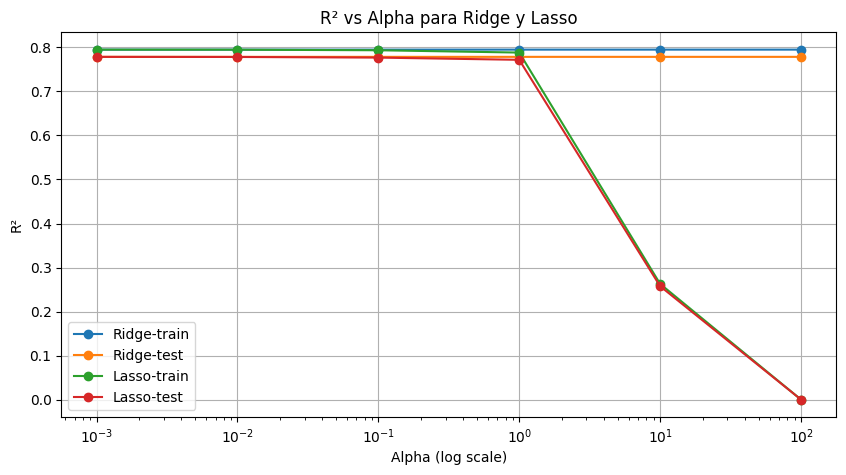

In [86]:
plt.figure(figsize=(10,5))
for model_name in ['Ridge','Lasso']:
    for conjunto in ['train','test']:
        subset = df_results[(df_results['Modelo']==model_name) & (df_results['Conjunto']==conjunto)]
        plt.plot(subset['Alpha'], subset['R2'], marker='o', label=f"{model_name}-{conjunto}")

plt.xscale('log')
plt.xlabel("Alpha (log scale)")
plt.ylabel("R²")
plt.title("R² vs Alpha para Ridge y Lasso")
plt.legend()
plt.grid(True)
plt.show()

**Observaciones:**

*Análisis del modelo Ridge*

El modelo demuestra que la regularización no fue la clave del éxito en este caso. El R² en el conjunto de entrenamiento (cercano a 0.804) y en el de prueba (cercano a 0.762) muestra que el modelo explica una gran parte de la variación, y aunque hay una ligera diferencia, no es un sobreajuste severo.
El MSE de prueba se mantiene prácticamente sin cambios, independientemente del valor de alpha. Esto demuestra que, para este modelo, aumentar el nivel de penalización con Ridge no perjudica significativamente el rendimiento, pero tampoco lo mejora.

*Análisis del modelo Lasso*

El comportamiento en esta ocasión es diferente y más sensible a los cambios en el valor de alpha.

Alpha bajo (0.001): con un alpha muy bajo, el modelo se comporta de manera idéntica a una regresión lineal simple, ya que la penalización es casi nula.

Alpha moderado (0.1 → 1): a medida que alpha aumenta, el R² de entrenamiento y prueba comienza a bajar, mientras que el MSE sube ligeramente. Esto indica que el modelo pierde precisión a medida que Lasso fuerza a algunos coeficientes a cero.

Alpha muy alto (10, 100): si el alpha es demasiado alto, la penalización es tan severa que todos los coeficientes se reducen a un punto en el que el R² cae a cero y el MSE se vuelve inmensamente grande. En este punto, el modelo se vuelve completamente inútil.

#### Comparación de modelos

In [79]:
# Modelos y sus hiperparámetros
modelos = [
    ("LinearRegression", LinearRegression(), None),
    ("Ridge", Ridge(alpha=1.0), 1.0),
    ("Lasso", Lasso(alpha=0.1, max_iter=10000), 0.1),
    ("ElasticNet", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000), 0.1)
]

resultados = []

for name, model, alpha in modelos:
    model.fit(X_train_scaled, y_train)
    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    resultados.append({
        "Modelo": name,
        "Alpha": alpha,
        "R2_train": r2_score(y_train, y_train_pred),
        "R2_test": r2_score(y_test, y_test_pred),
        "MSE_train": mean_squared_error(y_train, y_train_pred),
        "MSE_test": mean_squared_error(y_test, y_test_pred)
    })

# Resultados
comparacion = pd.DataFrame(resultados)
comparacion

,Modelo,Alpha,R2_train,R2_test,MSE_train,MSE_test
0,LinearRegression,NaN,0.809252,0.795547,17.018099,18.395463
1,Ridge,1.0,0.809252,0.795548,17.018099,18.395459
2,Lasso,0.1,0.808602,0.794778,17.076139,18.464691
3,ElasticNet,0.1,0.806612,0.793185,17.253614,18.608034


#### Conclusiones

Según la tabla, el mejor modelo es la Regresión Lineal. El modelo base tiene un rendimiento muy bueno, con un R² de 0.7955 en el conjunto de prueba y un MSE de 18.3954. Paralelamente, el análisis de los modelos de regularización muestra que no mejoran mucho el rendimiento.

Ridge: con un alpha de 1.0, las métricas son prácticamente idénticas a las de la regresión lineal, lo que confirma que la regularización no tuvo un impacto significativo.

Lasso y Elastic Net: con un alpha de 0.1, ambos modelos tienen métricas ligeramente peores que la regresión lineal. El R² de prueba de Lasso es 0.794778 y el de Elastic Net es 0.793185, ambos inferiores al R² de la regresión lineal.

En conclusión, la regresión lineal simple sigue siendo la mejor opción ya que las técnicas de regularización no aportaron mejoras al modelo.